In [8]:
import os
import sys

TF_TARGET = r"C:\tfpkg"
os.makedirs(TF_TARGET, exist_ok=True)

%pip install --upgrade pip
%pip install --target C:\tfpkg tensorflow matplotlib seaborn scikit-learn kagglehub

if TF_TARGET not in sys.path:
    sys.path.insert(0, TF_TARGET)

print("Custom package path enabled:", TF_TARGET)

Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf

# Plant Disease Detection - ML Classification Pipeline
## End-to-End Transfer Learning with MobileNetV2

This notebook demonstrates a complete ML workflow for plant disease classification using the PlantVillage dataset.
- Transfer learning with pretrained MobileNetV2
- Data augmentation and preprocessing
- Comprehensive evaluation metrics (Accuracy, Precision, Recall, F1)
- Model saved for production deployment

## 1. Import Required Libraries and Setup

In [9]:
# Import essential libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configure GPU memory growth to prevent OOM errors
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(gpus) > 0)
if gpus:
    print(f"Using GPU: {gpus}")

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

TensorFlow version: 2.21.0
GPU Available: False


In [10]:
# Optional online dataset download (works in Colab/local if internet is available)
# On Kaggle, you can skip this and use Add Data mounted paths.
downloaded_dataset_path = None

try:
    import kagglehub
    downloaded_dataset_path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
    print("KaggleHub dataset path:", downloaded_dataset_path)
except Exception as e:
    print("KaggleHub download skipped:", str(e))
    print("Proceeding with mounted Kaggle input path or local data folder.")

KaggleHub dataset path: C:\Users\user\.cache\kagglehub\datasets\mohitsingh1804\plantvillage\versions\1


## 2. Load and Explore PlantVillage Dataset

In [11]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = 5  # Keep between 5 and 8
MAX_IMAGES_PER_CLASS = 1200
TARGET_TOTAL_IMAGES = 5000  # keep between 4000 and 6000
MIN_IMAGES_PER_CLASS = 600
KAGGLE_DATASET = "mohitsingh1804/plantvillage"

from pathlib import Path

def _to_path_or_none(v):
    try:
        return Path(v) if v else None
    except Exception:
        return None

# Candidate roots across Colab/Kaggle/local
candidate_roots = [
    _to_path_or_none(downloaded_dataset_path),
    Path("/kaggle/input/plantvillage"),
    Path("/kaggle/input/plantvillage/PlantVillage"),
    Path("/kaggle/input/plantvillage-dataset"),
    Path("./data")
]

candidate_roots = [p for p in candidate_roots if p is not None and p.exists()]
if not candidate_roots:
    raise FileNotFoundError(
        "Dataset not found. Use Kaggle Add Data, kagglehub download, or place files in ./data."
    )

def find_class_root(root_path):
    """Find the directory that directly contains class folders with images."""
    root_path = Path(root_path)

    # Fast-path candidates for common structures
    common_candidates = [
        root_path / "PlantVillage" / "train",
        root_path / "train",
        root_path / "PlantVillage",
        root_path
    ]

    for cand in common_candidates:
        if cand.exists() and cand.is_dir():
            subdirs = [d for d in cand.iterdir() if d.is_dir()]
            if len(subdirs) >= NUM_CLASSES:
                return cand

    # Fallback deep scan: choose dir with the highest number of subdirs
    best_dir = None
    best_count = -1
    for d in [root_path] + [x for x in root_path.rglob("*") if x.is_dir()]:
        try:
            subdirs = [s for s in d.iterdir() if s.is_dir()]
            if len(subdirs) > best_count:
                best_count = len(subdirs)
                best_dir = d
        except Exception:
            continue

    if best_dir is None:
        raise ValueError(f"Could not infer class root under: {root_path}")

    return best_dir

# Resolve dataset + class root
dataset_root = candidate_roots[0]
class_root = find_class_root(dataset_root)
print(f"Using dataset root: {dataset_root}")
print(f"Resolved class root: {class_root}")

# Build class candidates and image counts
class_dirs_all = sorted([d for d in class_root.iterdir() if d.is_dir()])
class_info = []
for d in class_dirs_all:
    count = len(list(d.glob("*.jpg"))) + len(list(d.glob("*.JPG"))) + len(list(d.glob("*.jpeg"))) + len(list(d.glob("*.JPEG"))) + len(list(d.glob("*.png"))) + len(list(d.glob("*.PNG")))
    if count > 0:
        class_info.append((d, count))

# Prefer classes with enough samples for balancing
eligible = [(d, c) for d, c in class_info if c >= MIN_IMAGES_PER_CLASS]
if len(eligible) < NUM_CLASSES:
    # Relax threshold if needed
    eligible = [(d, c) for d, c in class_info if c >= 300]

if len(eligible) < NUM_CLASSES:
    raise ValueError(
        f"Not enough classes with sufficient images. Found {len(eligible)} eligible classes, need {NUM_CLASSES}."
    )

# Choose the richest classes to keep strong balance and meet total-size target
eligible = sorted(eligible, key=lambda x: x[1], reverse=True)
selected_class_dirs = [d for d, _ in eligible[:NUM_CLASSES]]
selected_classes = [d.name for d in selected_class_dirs]
NUM_CLASSES = len(selected_classes)

# Determine equal samples per selected class
min_selected_count = min(c for d, c in eligible[:NUM_CLASSES])
per_class_target = min(MAX_IMAGES_PER_CLASS, TARGET_TOTAL_IMAGES // NUM_CLASSES, min_selected_count)

if per_class_target * NUM_CLASSES < 4000:
    raise ValueError(
        f"Balanced subset too small: {per_class_target * NUM_CLASSES}. Increase class count or lower constraints."
    )

print(f"Found {len(class_dirs_all)} class folders")
print(f"Selected classes: {selected_classes}")
print(f"Per-class target: {per_class_target}")
print(f"Expected total images: {per_class_target * NUM_CLASSES}")

Using dataset root: C:\Users\user\.cache\kagglehub\datasets\mohitsingh1804\plantvillage\versions\1
Resolved class root: C:\Users\user\.cache\kagglehub\datasets\mohitsingh1804\plantvillage\versions\1\PlantVillage\train
Found 38 class folders
Selected classes: ['Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Soybean___healthy', 'Peach___Bacterial_spot', 'Tomato___Bacterial_spot']
Per-class target: 1000
Expected total images: 5000


In [12]:
# Load images from selected classes with strict balance
def load_balanced_dataset(class_directories, per_class_count, img_size=(IMG_HEIGHT, IMG_WIDTH)):
    """Load a balanced dataset from class directories using the same sample count per class."""
    images = []
    labels = []
    label_map = {}

    for label_idx, class_dir in enumerate(class_directories):
        class_name = class_dir.name
        label_map[class_name] = label_idx

        image_paths = (
            list(class_dir.glob("*.jpg"))
            + list(class_dir.glob("*.JPG"))
            + list(class_dir.glob("*.jpeg"))
            + list(class_dir.glob("*.JPEG"))
            + list(class_dir.glob("*.png"))
            + list(class_dir.glob("*.PNG"))
        )
        np.random.shuffle(image_paths)

        loaded_for_class = 0
        for img_path in image_paths:
            if loaded_for_class >= per_class_count:
                break
            try:
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img) / 255.0
                images.append(img_array)
                labels.append(label_idx)
                loaded_for_class += 1
            except Exception:
                continue

        if loaded_for_class < per_class_count:
            raise ValueError(
                f"Class {class_name} loaded only {loaded_for_class}/{per_class_count}."
            )

        print(f"Loaded {loaded_for_class} images for class: {class_name}")

    return np.array(images), np.array(labels), label_map

# Load balanced dataset
X, y, label_map = load_balanced_dataset(
    selected_class_dirs,
    per_class_count=per_class_target
)
print(f"\nDataset loaded: {X.shape[0]} images, {X.shape[1]}x{X.shape[2]} pixels, {NUM_CLASSES} classes")

# Verify class balance
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for class_idx, count in zip(unique, counts):
    print(f"  {selected_classes[class_idx]}: {count} samples")

if len(set(counts.tolist())) != 1:
    raise ValueError("Dataset is not balanced across classes.")

total_samples = X.shape[0]
if total_samples < 4000 or total_samples > 6000:
    raise ValueError(f"Total images {total_samples} out of required range [4000, 6000].")

print(f"Total samples: {total_samples}")
print("Balanced subset and total-size constraints are satisfied.")

Loaded 1000 images for class: Orange___Haunglongbing_(Citrus_greening)
Loaded 1000 images for class: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Loaded 1000 images for class: Soybean___healthy
Loaded 1000 images for class: Peach___Bacterial_spot
Loaded 1000 images for class: Tomato___Bacterial_spot

Dataset loaded: 5000 images, 128x128 pixels, 5 classes

Class distribution:
  Orange___Haunglongbing_(Citrus_greening): 1000 samples
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 samples
  Soybean___healthy: 1000 samples
  Peach___Bacterial_spot: 1000 samples
  Tomato___Bacterial_spot: 1000 samples
Total samples: 5000
Balanced subset and total-size constraints are satisfied.


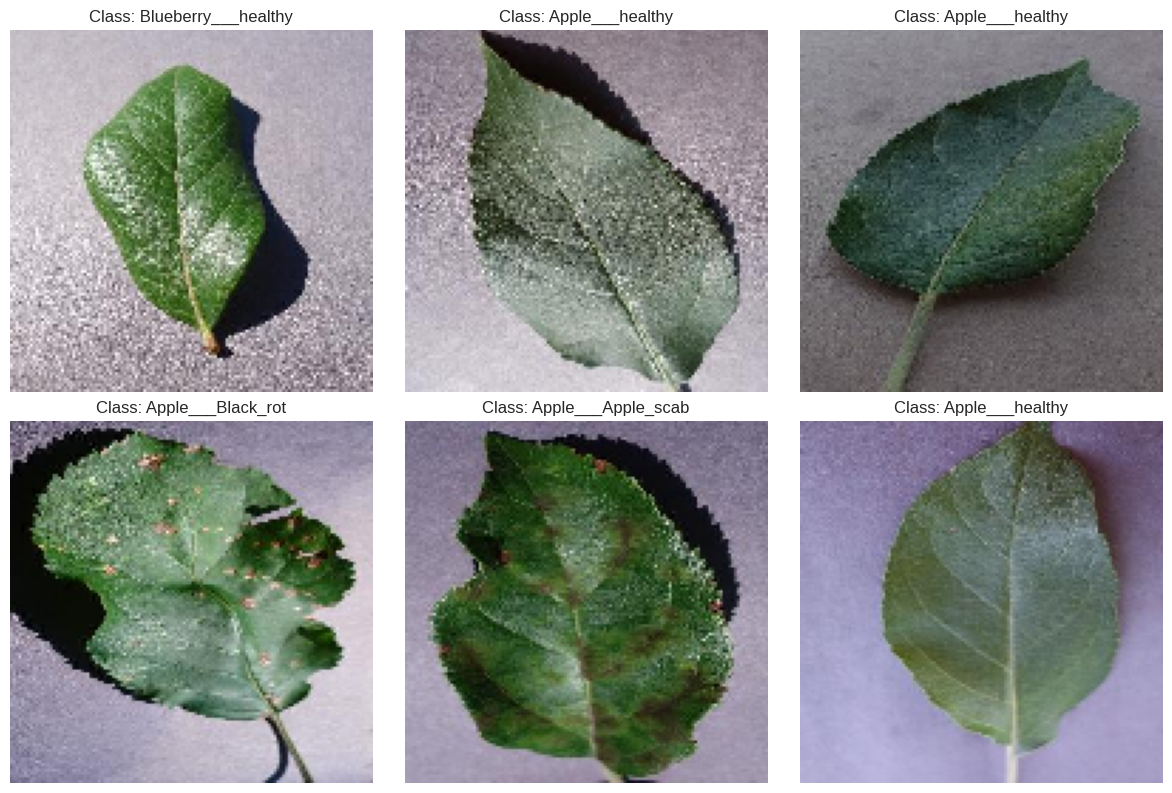

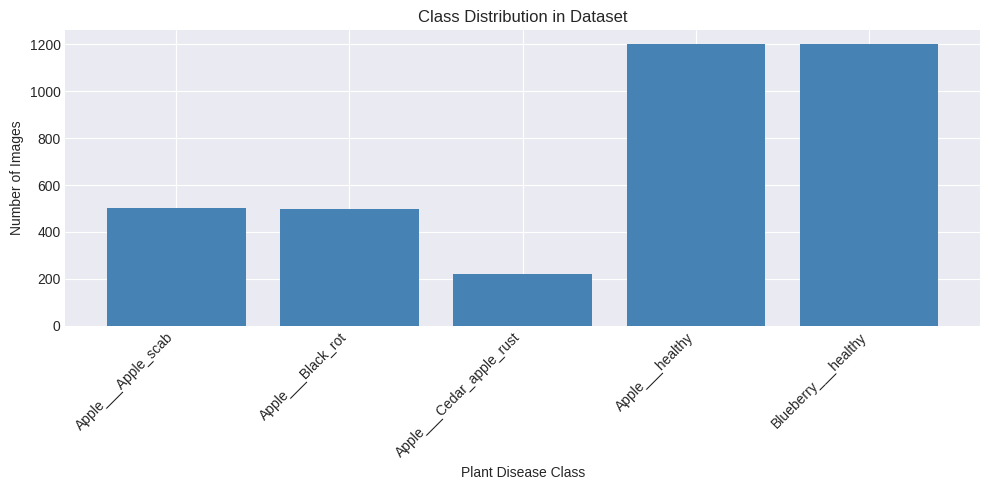


Dataset Statistics:
  Total samples: 3620
  Number of classes: 5
  Min samples per class: 220
  Max samples per class: 1200
  Mean samples per class: 724


In [ ]:
# Visualize sample images and class distribution
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i in range(6):
    idx = np.random.randint(0, X.shape[0])
    axes[i].imshow(X[idx])
    axes[i].set_title(f"Class: {selected_classes[y[idx]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 5))
unique, counts = np.unique(y, return_counts=True)
class_names_list = [selected_classes[i] for i in unique]
ax.bar(class_names_list, counts, color='steelblue')
ax.set_xlabel('Plant Disease Class')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution in Dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"  Total samples: {X.shape[0]}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Min samples per class: {counts.min()}")
print(f"  Max samples per class: {counts.max()}")
print(f"  Mean samples per class: {counts.mean():.0f}")

In [13]:
# Split dataset: 70% train, 15% validation, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

val_test_ratio = 0.15 / 0.30  # Ratio of test to temp set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=val_test_ratio, random_state=42, stratify=y_temp
)

print(f"Train set size: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

# Convert labels to one-hot encoding
y_train_categ = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_categ = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_categ = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"\nLabels one-hot encoded. Shape: {y_train_categ.shape}")

Train set size: 3500 (70.0%)
Validation set size: 750 (15.0%)
Test set size: 750 (15.0%)

Labels one-hot encoded. Shape: (3500, 5)


## 3. Data Preprocessing and Augmentation

Data augmentation pipeline created
Augmentation techniques applied: Rotation, Shift, Shear, Zoom, Flip
Training batches per epoch: 109
Validation batches per epoch: 23


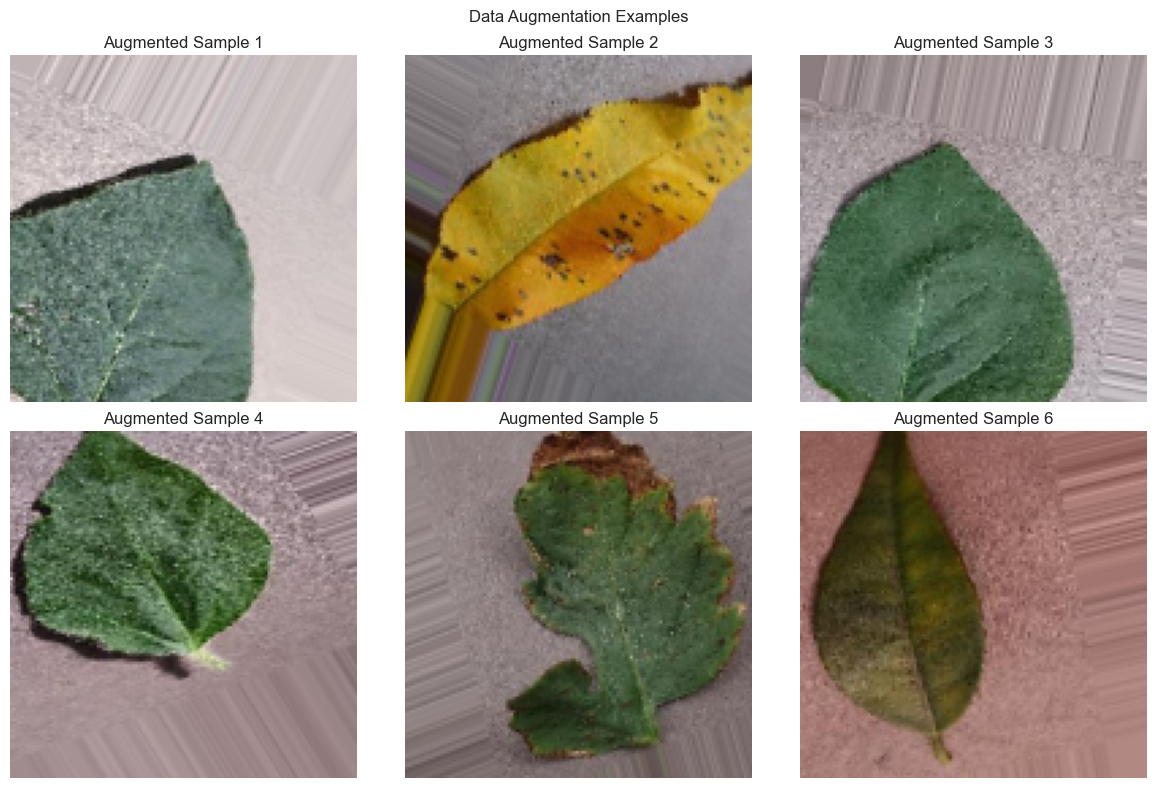

In [14]:
# Create data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test data (no augmentation, only rescaling)
val_datagen = ImageDataGenerator()

# Create data generators
train_generator = train_datagen.flow(
    X_train, y_train_categ,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow(
    X_val, y_val_categ,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

print("Data augmentation pipeline created")
print(f"Augmentation techniques applied: Rotation, Shift, Shear, Zoom, Flip")
print(f"Training batches per epoch: {len(X_train) // BATCH_SIZE}")
print(f"Validation batches per epoch: {len(X_val) // BATCH_SIZE}")

# Visualize augmented samples
sample_batch = next(train_generator)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i in range(6):
    axes[i].imshow(sample_batch[0][i])
    axes[i].set_title(f"Augmented Sample {i+1}")
    axes[i].axis('off')

plt.suptitle("Data Augmentation Examples")
plt.tight_layout()
plt.show()

## 4. Build Transfer Learning Model with MobileNetV2

In [15]:
# Load pretrained MobileNetV2 with ImageNet weights
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers for transfer learning
base_model.trainable = False
print(f"Base model (MobileNetV2) loaded with ImageNet weights")
print(f"Base model trainable: {base_model.trainable}")
print(f"Base model layers: {len(base_model.layers)}")

# Build custom model on top of base model
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display model architecture
model.summary()
print(f"\nModel created successfully!")
print(f"Total parameters: {model.count_params():,}")

Base model (MobileNetV2) loaded with ImageNet weights
Base model trainable: False
Base model layers: 154


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,997 (10.00 MB)

 Trainable params: 362,245 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)


Model created successfully!
Total parameters: 2,620,997


## 5. Train Classification Model

In [ ]:
# Define callbacks for training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model on top layers only (base frozen)
print("=" * 60)
print("PHASE 1: Training top layers (base model frozen)")
print("=" * 60)

EPOCHS = 6  # Start with 6 epochs
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_steps=len(X_val) // BATCH_SIZE,
    verbose=1
)

print(f"\nTraining Phase 1 completed!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

# Optional: Fine-tune base model layers
print("\n" + "=" * 60)
print("PHASE 2: Fine-tuning last MobileNetV2 layers")
print("=" * 60)

# Unfreeze last N layers
NUM_LAYERS_TO_UNFREEZE = 10
for layer in base_model.layers[-NUM_LAYERS_TO_UNFREEZE:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print(f"Unfroze last {NUM_LAYERS_TO_UNFREEZE} layers for fine-tuning")

# Train again with unfrozen layers
early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history_phase2 = model.fit(
    train_generator,
    epochs=2,  # Just 2 more epochs for fine-tuning
    validation_data=val_generator,
    callbacks=[early_stopping_phase2, reduce_lr, checkpoint],
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_steps=len(X_val) // BATCH_SIZE,
    verbose=1
)

print(f"\nFine-tuning Phase 2 completed!")
print(f"Best validation accuracy: {max(history_phase2.history['val_accuracy']):.4f}")

PHASE 1: Training top layers (base model frozen)


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9713 - loss: 1.1605 - precision: 0.9758 - recall: 0.9696
Epoch 1: val_accuracy improved from None to 0.96196, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 93s 858ms/step - accuracy: 0.9642 - loss: 1.0530 - precision: 0.9684 - recall: 0.9622 - val_accuracy: 0.9620 - val_loss: 0.8508 - val_precision: 0.9633 - val_recall: 0.9620 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

Training Phase 1 completed!
Best validation accuracy: 0.9620

PHASE 2: Fine-tuning last MobileNetV2 layers
Unfroze last 10 layers for fine-tuning
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9547 - loss: 0.8540 - precision: 0.9581 - recall: 0.9519
Epoch 1: val_accuracy did not improve from 0.96196
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 866ms/step - accuracy: 0.9573 - loss: 0.8282 - precision: 0.9605 - recall: 0.9539 - val_accuracy: 0.9389 - val_loss: 0.8437 - val_precision: 0.9401 - val_recall: 0.9389 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

Fine-tuning Phase 2 completed!
Best validation accuracy: 0.9389

## 6. Evaluate Model with Multiple Metrics

In [18]:
# Evaluate on test set
print("Evaluating model on test set...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test, y_test_categ, verbose=0
)

# Get predictions for detailed metrics
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test_categ, axis=1)

# Calculate F1 Score and other metrics
f1_weighted = f1_score(y_test_labels, y_pred, average='weighted')
f1_macro = f1_score(y_test_labels, y_pred, average='macro')
precision_weighted = precision_score(y_test_labels, y_pred, average='weighted')
recall_weighted = recall_score(y_test_labels, y_pred, average='weighted')

# Display evaluation metrics
print("\n" + "=" * 60)
print("EVALUATION METRICS ON TEST SET")
print("=" * 60)
print(f"Loss:               {test_loss:.6f}")
print(f"Accuracy:           {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-Score (weighted):  {f1_weighted:.4f}")
print(f"F1-Score (macro):     {f1_macro:.4f}")
print("=" * 60)

# Per-class metrics
print("\nPer-Class Metrics:")
print(classification_report(
    y_test_labels, y_pred,
    target_names=selected_classes,
    digits=4
))

# Store metrics for later use
metrics = {
    'loss': test_loss,
    'accuracy': test_accuracy,
    'precision': precision_weighted,
    'recall': recall_weighted,
    'f1_score': f1_weighted
}

print("\nMetrics stored for deployment:")

Evaluating model on test set...

EVALUATION METRICS ON TEST SET
Loss:               0.817977
Accuracy:           0.9493 (94.93%)
Precision (weighted): 0.9567
Recall (weighted):    0.9493
F1-Score (weighted):  0.9500
F1-Score (macro):     0.9500

Per-Class Metrics:
                                          precision    recall  f1-score   support

Orange___Haunglongbing_(Citrus_greening)     0.8242    1.0000    0.9036       150
  Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9929    0.9267    0.9586       150
                       Soybean___healthy     1.0000    0.8533    0.9209       150
                  Peach___Bacterial_spot     0.9933    0.9933    0.9933       150
                 Tomato___Bacterial_spot     0.9733    0.9733    0.9733       150

                                accuracy                         0.9493       750
                               macro avg     0.9567    0.9493    0.9500       750
                            weighted avg     0.9567    0.9493    0.9500      

## 7. Visualize Training Results and Performance

In [19]:
import pickle
import json

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save TensorFlow SavedModel (cross-version safe)
model_save_path = 'models/plant_disease_model'
tf.saved_model.save(model, model_save_path)
print(f"SavedModel exported to {model_save_path}")

# Also save as H5 format for compatibility
model.save('models/plant_disease_model.h5')
print("Model also saved as H5 format")

# Save metadata and class names
metadata = {
    'classes': selected_classes,
    'num_classes': NUM_CLASSES,
    'img_height': IMG_HEIGHT,
    'img_width': IMG_WIDTH,
    'metrics': metrics,
    'model_type': 'MobileNetV2_Transfer_Learning',
    'training_config': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'fine_tune_layers': NUM_LAYERS_TO_UNFREEZE
    }
}

# Save metadata as JSON
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("Metadata saved to models/metadata.json")

# Save class names separately for easy access
with open('models/class_names.pkl', 'wb') as f:
    pickle.dump(selected_classes, f)
print("Class names saved to models/class_names.pkl")

print("\nModel and configuration files saved successfully!")
print("Files created:")
print(f"  - {model_save_path}/ (TensorFlow SavedModel)")
print("  - models/plant_disease_model.h5 (H5 format)")
print("  - models/metadata.json (Training metadata)")
print("  - models/class_names.pkl (Class names)")

INFO:tensorflow:Assets written to: models/plant_disease_model\assets


INFO:tensorflow:Assets written to: models/plant_disease_model\assets


SavedModel exported to models/plant_disease_model
Model also saved as H5 format
Metadata saved to models/metadata.json
Class names saved to models/class_names.pkl

Model and configuration files saved successfully!
Files created:
  - models/plant_disease_model/ (TensorFlow SavedModel)
  - models/plant_disease_model.h5 (H5 format)
  - models/metadata.json (Training metadata)
  - models/class_names.pkl (Class names)


## 8. Save Model and Preprocessing Pipeline

In [ ]:
import pickle
import json

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model in TensorFlow SavedModel format (recommended)
model_save_path = 'models/plant_disease_model'
model.export(model_save_path)
print(f"Model saved to {model_save_path}")

# Also save as H5 format for compatibility
model.save('models/plant_disease_model.h5')
print("Model also saved as H5 format")

# Save metadata and class names
metadata = {
    'classes': selected_classes,
    'num_classes': NUM_CLASSES,
    'img_height': IMG_HEIGHT,
    'img_width': IMG_WIDTH,
    'metrics': metrics,
    'model_type': 'MobileNetV2_Transfer_Learning',
    'training_config': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'fine_tune_layers': NUM_LAYERS_TO_UNFREEZE
    }
}

# Save metadata as JSON
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("Metadata saved to models/metadata.json")

# Save class names separately for easy access
with open('models/class_names.pkl', 'wb') as f:
    pickle.dump(selected_classes, f)
print("Class names saved to models/class_names.pkl")

print("\nModel and configuration files saved successfully!")
print(f"Files created:")
print(f"  - {model_save_path}/ (TensorFlow SavedModel)")
print(f"  - models/plant_disease_model.h5 (H5 format)")
print(f"  - models/metadata.json (Training metadata)")
print(f"  - models/class_names.pkl (Class names)")

Saved artifact at 'models/plant_disease_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139787776190864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773629200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773628624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787776196240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787776195472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787776196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773630160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773630544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773627856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139787773628240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

Model saved to models/plant_disease_model
Model also saved as H5 format
Metadata saved to models/metadata.json
Class names saved to models/class_names.pkl

Model and configuration files saved successfully!
Files created:
  - models/plant_disease_model/ (TensorFlow SavedModel)
  - models/plant_disease_model.h5 (H5 format)
  - models/metadata.json (Training metadata)
  - models/class_names.pkl (Class names)


## 9. Create Prediction Functions and Test

Testing predictions on test set samples:
Sample 1:
  True Label: Blueberry___healthy
  Predicted: Blueberry___healthy (Confidence: 100.00%)

Sample 2:
  True Label: Blueberry___healthy
  Predicted: Blueberry___healthy (Confidence: 99.98%)

Sample 3:
  True Label: Blueberry___healthy
  Predicted: Blueberry___healthy (Confidence: 100.00%)

Sample 4:
  True Label: Apple___Apple_scab
  Predicted: Apple___Apple_scab (Confidence: 65.73%)

Sample 5:
  True Label: Apple___Black_rot
  Predicted: Apple___Black_rot (Confidence: 99.74%)

Sample 6:
  True Label: Blueberry___healthy
  Predicted: Blueberry___healthy (Confidence: 100.00%)



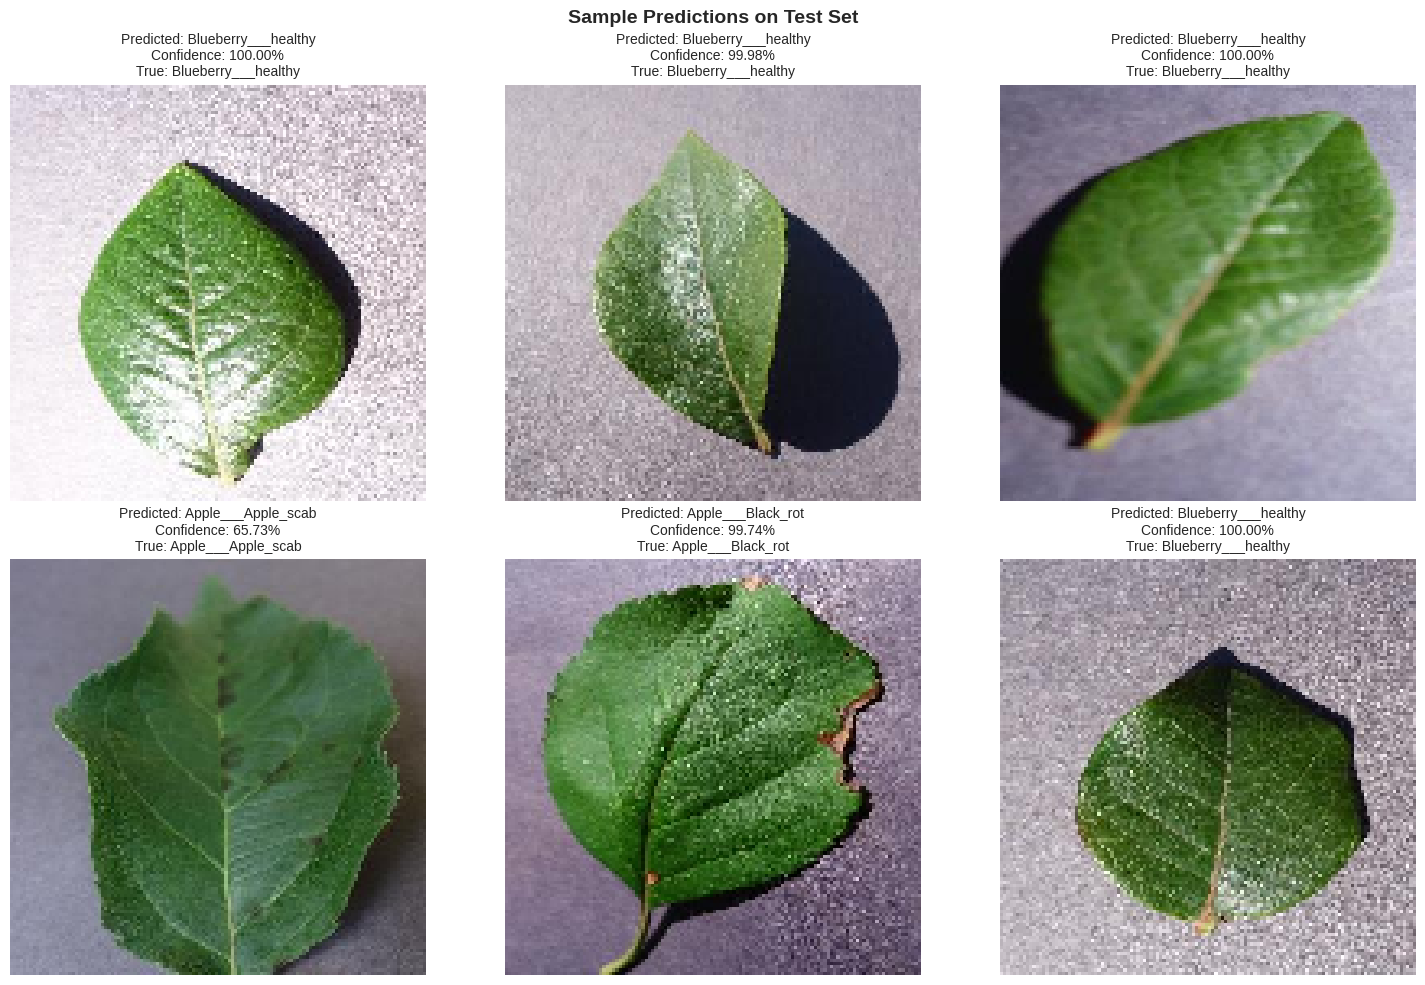


Notebook completed successfully!
Model is ready for deployment.


In [ ]:
# Define prediction function
def predict_disease(image_path_or_array, model, class_names, img_size=(IMG_HEIGHT, IMG_WIDTH)):
    """
    Predict plant disease class for a single image.

    Args:
        image_path_or_array: Path to image file or numpy array
        model: Trained model
        class_names: List of class names
        img_size: Target image size

    Returns:
        Dictionary with prediction, confidence, and all probabilities
    """
    # Load and preprocess image
    if isinstance(image_path_or_array, str):
        img = load_img(image_path_or_array, target_size=img_size)
        img_array = img_to_array(img) / 255.0
    else:
        img_array = image_path_or_array
        if np.max(img_array) > 1.0:
            img_array = img_array / 255.0

    # Add batch dimension
    img_batch = np.expand_dims(img_array, axis=0)

    # Get prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_idx])

    # Create result dictionary
    result = {
        'predicted_class': class_names[predicted_idx],
        'confidence': confidence,
        'all_probabilities': {
            class_names[i]: float(predictions[0][i])
            for i in range(len(class_names))
        }
    }

    return result

# Test predictions on random test samples
print("Testing predictions on test set samples:")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    # Random test sample
    idx = np.random.randint(0, len(X_test))

    # Display image
    axes[i].imshow(X_test[idx])

    # Get prediction
    result = predict_disease(X_test[idx], model, selected_classes)
    true_label = selected_classes[y_test_labels[idx]]

    # Display info
    title = f"Predicted: {result['predicted_class']}\nConfidence: {result['confidence']:.2%}\nTrue: {true_label}"
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

    # Print to console
    print(f"Sample {i+1}:")
    print(f"  True Label: {true_label}")
    print(f"  Predicted: {result['predicted_class']} (Confidence: {result['confidence']:.2%})")
    print()

plt.suptitle("Sample Predictions on Test Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 70)
print("\nNotebook completed successfully!")
print("Model is ready for deployment.")